# Implementing `BERT: Pre-training of Deep Bidirectional Transformers for Language Understanding` From Scratch

## Part 1: A Foundational Analysis of BERT

### Section 1: The Pre-BERT Landscape and the Need for Bidirectional Understanding

The central challenge in **Natural Language Processing (NLP)** has long been the development of models that can capture the rich, contextual meaning of human language. BERT was not an isolated invention but a direct and elegant solution to a well-defined set of limitations present in prior state-of-the-art models. <br>

**The Problem with Context-Free Embeddings:**<br>
Early successes in neural language modeling such as Word2Vec and GloVe revolutionized NLP by learning dense vector representations (embeddings) for words. These models operated on a simple principle: words that appear in similar contexts should have similar vector representations. This allowed models to capture semantic relationships, famously enabling vector arithmetic like:<br>
$king - man + woman ≈ queen.$<br>
But these embeddings were fundamentally static and context-free. The word "bank" for example, would have the exact same vector representation in "the river bank" and "the money in the bank." This inability to disambiguate words based on their surrounding texts a phenomenon known as **polysemy** posed a significant ceiling on the performance of downstream NLP tasks. The field needed representations that were dynamic and sensitive to context.<br>

Before BERT the dominant paradigm in NLP was to use language models that were unidirectional. Models like the canonical LSTMs or state-of-the-art GPT from OpenAI processed text sequentially either from left-to-right or right-to-left. <br>
Consider the sentence: *The man went to the bank to deposit money.* A left-to-right model would understand **bank** based only on *The man went to the...*. It couldn't use the crucial context **to deposit money** that comes after. This is a fundamental limitation because human language comprehension is not sequential it's holistic. We use the entire sentence to disambiguate meaning.

### Section-2: Assumptions, Goals, and Research Questions

- #### Primary Assumption
The paper assumes that a model pre-trained on a massive unlabeled text corpus can learn universal language representations that are beneficial for a wide variety of downstream NLP tasks (e.g., sentiment analysis, question answering). This builds upon prior work like Word2Vec and ELMo.

- #### Central Goal
To demonstrate that a deeply bidirectional model when pre-trained effectively will outperform unidirectional or shallowly bidirectional models across a wide range of NLP benchmarks and will establish a new state-of-the-art.

- #### Key Research Questions

1. Can the Transformer architecture originally designed for sequence-to-sequence tasks be adapted for language representation pre-training?
2. How can we train a truly bidirectional model given that seeing the whole sentence makes predicting the next word trivial?
3. Is learning inter-sentence relationships (like whether one sentence follows another) as important as learning intra-sentence relationships (word meanings)?
4. Can this pre-trained model be effectively fine-tuned for various tasks with minimal architectural changes, making it a general-purpose NLP backbone?

### 3. Methodology: Pre-training Tasks

We can't just feed a sentence to a bidirectional model and ask it to predict the next word, because it can already *see* the answer. There are two unsupervised pre-training tasks in the paper to solve this.

#### Task 1: Masked Language Model (MLM)

This is the core innovation that enables deep bidirectionality. It's inspired by the [Cloze task](https://www.teachingenglish.org.uk/professional-development/teachers/knowing-subject/c/cloze) which is a common reading comprehension test.

1. **Masking**: Before feeding a sentence to the model we randomly mask 15% of the tokens.
2. **The 80-10-10 Rule:** From the tokens we have chosen for masking:

    - 80% of the time the token is replaced with a special [MASK] token.
    - 10% of the time the token is replaced with a random token from the vocabulary.
    - 10% of the time the token is left unchanged.
3. **Objective:** The model's goal is to predict the original identity of the masked token based on the unmasked context from both left and right.

> Why the 80-10-10 split? 

It's an approach to reduce a mismatch between pre-training and fine-tuning. If we always use `[MASK]` the model would never learn good representations for actual words during pre-training and the `[MASK]` token would never appear during fine-tuning. By sometimes using a random word the model is forced to learn to correct it. By sometimes using the original word it biases the model towards the true representation.

**Example:**
- Original: The man went to the bank to deposit money.
- Masked Input: The man went to the `[MASK]` to `[MASK]` money.
- Model's Goal: Predict bank and deposit for the respective `[MASK]` positions.




#### Task 2: Next Sentence Prediction (NSP)

This task aims to teach the model to understand sentence relationships.

1. **Data Generation:** The training data is composed of sentence pairs (A, B).

    - 50% of the time sentence B is the actual sentence that follows sentence A in the corpus (labeled `IsNext`).
    - 50% of the time sentence B is a random sentence from the corpus (labeled `NotNext`).
2. **Objective:** The model must predict whether sentence B is the true next sentence for A. This prediction is made using the output of the special `[CLS]` token that is prepended to every input sequence.

**Example:**
- **Input A:** The man went to the bank.
- **Input B** (`IsNext`): He wanted to deposit his money. -> Label: `IsNext`
- **Input B** (`NotNext`): Penguins are flightless birds. -> Label: `NotNext`



## Part-2: Implementation from Scratch of BERT

### Section 1: Setup

In [143]:
import math
import torch
import numpy as np
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader

### Section-2: Configuration of Model

In [126]:
# class to hold parameters
class BERTConfig:
    # here 768 is the d_model in the original BERT paper
    # 12 is the number of layers in the original BERT paper(encoder blocks
    # 12 is the number of attention heads in the original BERT paper
    # 3072 is the intermediate size in the original BERT paper
    # 512 is the maximum position embeddings in the original BERT paper
    # 2 is the type vocab size in the original BERT paper
    # 0.1 is the dropout probability in the original BERT paper)
    def __init__(self,vocab_size=30, hidden_size=768, num_hidden_layers=12, num_attention_heads=12,
                 intermediate_size=3072, max_position_embeddings=512, type_vocab_size=2, hidden_dropout_prob=0.1):
        # initialising the BERT configuration parameters
        self.vocab_size = vocab_size
        self.hidden_size = hidden_size
        self.num_hidden_layers = num_hidden_layers
        self.num_attention_heads = num_attention_heads
        self.attention_head_size = hidden_size // num_attention_heads
        self.intermediate_size = intermediate_size
        self.max_position_embeddings = max_position_embeddings
        self.type_vocab_size = type_vocab_size
        self.hidden_dropout_prob = hidden_dropout_prob


# using smaller dimensions for toy model
config = BERTConfig(vocab_size=30,hidden_size=128,num_hidden_layers=2,num_attention_heads=2,
    intermediate_size=128 * 4, max_position_embeddings=512, type_vocab_size=2, hidden_dropout_prob=0.1)

### Section-3: Building the BERT Components

- #### 3.1: Implementing Scaled Dot-Product Attention

Building the core of the attention mechanism:
```math
\text{Attention}(Q, K, V) = \text{softmax}\left( \frac{QK^\top}{\sqrt{d_k}} \right)V
```

Where:

* `Q` = Query matrix
* `K` = Key matrix
* `V` = Value matrix
* `d_k` = Dimension of the key vectors (used for scaling)
* `softmax` = Function to normalize attention scores into probabilities


In [127]:
class ScaledDotProductAttention(nn.Module):
    
    def __init__(self):
        super(ScaledDotProductAttention, self).__init__()# initialising the parent class
        
    def forward(self, Q,K,V, attention_mask):
        # Q, K, V are the query, key and value matrices with Q, K, V: [batch_size, n_heads, seq_len, head_dim]
        # attention mask is a mask to avoid attention on padding tokens with [batch_size, 1, seq_len, seq_len]
        scores = torch.matmul(Q, K.transpose(-1, -2)) / np.sqrt(Q.shape[-1]) # scaling the scores by the square root of the head dimension
        scores = scores + attention_mask# fill masked positions with a large negative value        
        attention_probs = nn.Softmax(dim = -1)(scores)  # softmax to get attention probabilities
        context = torch.matmul(attention_probs, V)  # context vector is the weighted sum of values for each token 
        
        # context shape: [batch_size, n_heads, seq_len, head_dim]
        return context

- #### 3.2: Multi-Head Attention

Implementing scaled dot-product atttention multiple times in parallel.

In [128]:
class MultiHeadAttention(nn.Module):
    
    def __init__(self, config):
        super(MultiHeadAttention, self).__init__()# initialising the parent class
        self.n_heads = config.num_attention_heads# number of attention heads
        self.head_dim = config.attention_head_size# dimension of each attention head
        self.hidden_size = config.hidden_size# hidden size of the model from config
        
        # linear layers to project the input to query, key and value matrices
        self.W_Q = nn.Linear(self.hidden_size, self.n_heads * self.head_dim)# linear layer for queries
        self.W_K = nn.Linear(self.hidden_size, self.n_heads * self.head_dim)# linear layer for keys
        self.W_V = nn.Linear(self.hidden_size, self.n_heads * self.head_dim)# linear layer for values
        
        self.attention = ScaledDotProductAttention()# scaled dot product attention layer
        self.output_linear = nn.Linear(self.n_heads * self.head_dim, self.hidden_size)# linear layer to project the output back to hidden size
        self.dropout = nn.Dropout(config.hidden_dropout_prob)# dropout layer for regularization
        
    def forward(self, hidden_states, attention_mask):
        # hidden_states shape: [batch_size, seq_len, hidden_size]
        batch_size = hidden_states.size(0)# batch size
        
        # projecting and reshaping the hidden states to get Q, K, V
        q = self.W_Q(hidden_states).view(batch_size, -1, self.n_heads, self.head_dim).transpose(1, 2) # [batch_size, n_heads, seq_len, head_dim]
        k = self.W_K(hidden_states).view(batch_size, -1, self.n_heads, self.head_dim).transpose(1, 2) # [batch_size, n_heads, seq_len, head_dim]
        v = self.W_V(hidden_states).view(batch_size, -1, self.n_heads, self.head_dim).transpose(1, 2) # [batch_size, n_heads, seq_len, head_dim]
        
        # applying attention
        context = self.attention(q, k, v, attention_mask)# [batch_size, n_heads, seq_len, head_dim]
        
        # concating heads and applying the output linear layer
        context = context.transpose(1, 2).reshape(batch_size, -1, self.n_heads * self.head_dim) # [batch_size, seq_len, n_heads * head_dim]
        output = self.output_linear(context)
        output = self.dropout(output)  # applying dropout
        
        # output shape: [batch_size, seq_len, hidden_size]
        return output

- #### Position-wise Feed-Forward Network

Implementing a simple two-layer fully connected network applied to each position.

In [129]:
class PositionWiseFeedForward(nn.Module):
    
    def __init__(self, config):
        super(PositionWiseFeedForward, self).__init__()
        self.fc1 = nn.Linear(config.hidden_size, config.intermediate_size)# linear layer to project to intermediate size
        self.fc2 = nn.Linear(config.intermediate_size, config.hidden_size)# linear layer to project back to hidden size
        self.activation = nn.GELU()# activation function(GELU because it is used in BERT)
    
    def forward(self, x):
        return self.fc2(self.activation(self.fc1(x)))  # applying the two linear layers with activation in between

- #### 3.4 BERT Encoder Layer

Implementing a single BERT layer where we are combining Multi-Head Attention and the FFN.

In [130]:
class EncoderLayer(nn.Module):
    def __init__(self, config):
        super(EncoderLayer, self).__init__() # initialising the parent class
        self.attention = MultiHeadAttention(config) # multi-head attention layer
        self.ffn = PositionWiseFeedForward(config) # position-wise feed-forward network
        self.layernorm1 = nn.LayerNorm(config.hidden_size, eps=1e-12) # layer normalization after attention
        self.layernorm2 = nn.LayerNorm(config.hidden_size, eps=1e-12) # layer normalization after feed-forward network
        self.dropout = nn.Dropout(config.hidden_dropout_prob)
    
    def forward(self, hidden_states, attention_mask):
        # adding Multi-Head Attention + Add & Norm
        attn_output = self.attention(hidden_states, attention_mask)# [batch_size, seq_len, hidden_size]
        attn_output = self.dropout(attn_output)# applying dropout
        x = self.layernorm1(hidden_states + attn_output)# adding the residual connection and applying layer normalization

        # adding Feed-Forward Network + Add & Norm
        ffn_output = self.ffn(x)
        ffn_output = self.dropout(ffn_output)
        x = self.layernorm2(x + ffn_output)

        # x: [batch_size, seq_len, hidden_size]
        return x

- #### 3.5 BERT Embeddings

Combining token, position, and segment embeddings.

In [131]:
class BERTEmbeddings(nn.Module):
    def __init__(self, config):
        super(BERTEmbeddings, self).__init__()
        self.token_embeddings = nn.Embedding(config.vocab_size, config.hidden_size, padding_idx=0)# token embeddings
        self.position_embeddings = nn.Embedding(config.max_position_embeddings, config.hidden_size)# position embeddings
        self.segment_embeddings = nn.Embedding(config.type_vocab_size, config.hidden_size)# segment embeddings
        self.LayerNorm = nn.LayerNorm(config.hidden_size, eps=1e-12)
        self.dropout = nn.Dropout(config.hidden_dropout_prob)# dropout layer for regularization
        
    def forward(self, input_ids, segment_ids):
        seq_length = input_ids.size(1)  # sequence length
        position_ids = torch.arange(seq_length, dtype=torch.long, device=input_ids.device)
        position_ids = position_ids.unsqueeze(0).expand_as(input_ids)
        
        tokens_embed = self.token_embeddings(input_ids)  # token embeddings
        position_embed = self.position_embeddings(position_ids)  # position embeddings
        segment_embed = self.segment_embeddings(segment_ids)  # segment embeddings
        
        # summing the embeddings
        embeddings = tokens_embed + position_embed + segment_embed
        embeddings = self.LayerNorm(embeddings)  # layer normalization
        embeddings = self.dropout(embeddings)  # applying dropout
        
        return embeddings  # [batch_size, seq_len, hidden_size]

### Section-4: Assembling the Complete BERT MODEL

In [132]:
class BERTModel(nn.Module):
    def __init__(self, config):
        super(BERTModel, self).__init__()
        self.embeddings = BERTEmbeddings(config)  # BERT embeddings
        self.encoder_layers = nn.ModuleList([EncoderLayer(config) for _ in range(config.num_hidden_layers)])# creating multiple encoder layers
    
    def forward(self, input_ids, segment_ids, attention_mask):
        """
        Shapes:
        input_ids and segment_ids: [batch_size, seq_len]
        attention_mask: [batch_size, seq_len]
        """
        embedding_output = self.embeddings(input_ids, segment_ids)  # getting the embeddings
        
        """
        Reshaping attention_mask to match the shape of the embeddings of attention mechanism
        [batch_size, seq_len] -> [batch_size, 1, 1, seq_len] where 1, 1 are for n_heads and seq_len respectively
        This is done to avoid attention on padding tokens and broadcast across heads and query positions.
        """
        extended_attention_mask = attention_mask.unsqueeze(1).unsqueeze(2)  # [batch_size, 1, 1, seq_len]
        extended_attention_mask = (1.0 - extended_attention_mask) * -10000.0  #for masking
        
        hidden_states = embedding_output  # initial hidden states from embeddings
        for layer in self.encoder_layers:
            hidden_states = layer(hidden_states, extended_attention_mask)  # passing through each encoder layer
        
        # final hidden states after passing through all encoder layers
        return hidden_states # [batch_size, seq_len, hidden_size]

- #### 4.1: Pre-training BERT Head

This class combines the BERT model with the heads for Masked Language Model(MLM) and Next Sentence Prediction(NSP).

In [133]:
class BERTForPreTraining(nn.Module):
    def __init__(self, config):
        super(BERTForPreTraining, self).__init__()
        self.bert = BERTModel(config)
        
        # Masked Language Model (MLM) head
        self.mlm_head = nn.Linear(config.hidden_size, config.vocab_size)  # linear layer to project to vocab size
        
        # Next Sentence Prediction (NSP) head
        self.nsp_pooler = nn.Linear(config.hidden_size, config.hidden_size)  # linear layer to pool the hidden states for NSP
        self.nsp_classisfier = nn.Linear(config.hidden_size, 2)  # linear layer to classify next sentence prediction IsNext or NotNext
        self.nsp_activation = nn.Tanh()  # activation function for NSP head
        
    def forward(self, input_ids, segment_ids, attention_mask):
        sequence_output = self.bert(input_ids, segment_ids, attention_mask)  # getting the sequence output from BERT
        
        # Uding [CLS] for NSP for output of the first token
        pooled_output = self.nsp_activation(self.nsp_pooler(sequence_output[:, 0]))# [batch_size, hidden_size]
        nsp_logits = self.nsp_classisfier(pooled_output)  # getting the logits for NSP
        # For MLM we use the entire sequence output
        mlm_logits = self.mlm_head(sequence_output)
        
        return mlm_logits, nsp_logits

### Section-5: Prearing Data for Pre-Training

Creating a small toy corpus and functions to generate pre-training samples.

- #### 5.1: Toy Corpus and Vocabulary

In [134]:
sentences = [
    "The cat sat on the mat.",
    "The dog ate my homework.",
    "Cats and dogs are great pets.",
    "He read a book by the window.",
    "The sun shines brightly in the sky.",
    "She walked through the green park.",
    "A bird sang a sweet song.",
    "The moon cast a silver light."
]

In [135]:
# Building a toy vocabulary with Special Tokens: [PAD], [CLS], [SEP], [MASK]
# Preprocess sentences: lowercase and remove periods before building vocab
preprocessed_sentences = [s.lower().replace('.', '') for s in sentences]
word_list = " ".join(preprocessed_sentences).split()  # joining and splitting into words
vocab = list(set(word_list))  # unique words
word2idx = {'[PAD]': 0, '[CLS]': 1, '[SEP]': 2, '[MASK]': 3}  # add special tokens
for i, w in enumerate(vocab):
    word2idx[w] = i + 4  # start from 4 for special tokens
idx2word = {i: w for w, i in word2idx.items()}
vocab_size = len(word2idx)

# update vocab_size in config
config.vocab_size = vocab_size

# tokenize sentences using the same preprocessing
tokenized_sentences = [[word2idx[word] for word in s.split()] for s in preprocessed_sentences]

- #### 5.2: Creating Pre-training Sample Generation

In [136]:
#creting single pretraining sample for BERT
def create_pretraining_sample(sentences, max_seq_len, max_predictions):
    
    #deciding if the second sentence is next or random
    sent_a_idx = np.random.randint(len(sentences))  # random index for first sentence
    sent_b_idx = -1# if next sentence is random
    if np.random.random()> 0.5:  # 50% chance to select next sentence
        is_next = True
        sent_b_idx = sent_a_idx + 1
        if sent_b_idx >= len(sentences):  # if it goes out of bounds, select a random sentence
            sent_b_idx = np.random.randint(len(sentences)) # random index for second sentence
            is_next = False# if next sentence is random
    else:
        is_next = False
        sent_b_idx = np.random.randint(len(sentences))  # random index for second sentence
        # looking it's not the same or the actual next sentence
        while sent_b_idx == sent_a_idx or sent_b_idx == sent_a_idx + 1:
            sent_b_idx = np.random.randint(len(sentences))# random index for second sentence
    
    # tokenizing the sentences
    tokens_a = sentences[sent_a_idx]# tokenized first sentence
    tokens_b = sentences[sent_b_idx]# tokenized second sentence
    
    # Combining sentences with special tokens
    input_ids = [word2idx['[CLS]']] + tokens_a + [word2idx['[SEP]']] + tokens_b + [word2idx['[SEP]']]
    segment_ids = [0] * (len(tokens_a) + 2) + [1] * (len(tokens_b) + 1)# segment ids for first and second sentences
    
    #implementing masking for MLM
    n_pred = min(max_predictions, max(1, int(round(len(input_ids) * 0.15))))# number of predictions(15% of input_ids)
    # randomly selecting positions to mask
    cand_masked_pos = [i for i, token in enumerate(input_ids) if token not in [word2idx['[CLS]'], word2idx['[SEP]']]]
    np.random.shuffle(cand_masked_pos)  # shuffling the positions for the purpose of randomness
    masked_tokens = []# list to hold masked tokens
    masked_pos =[]# list to hold positions of masked tokens
    
    for pos in cand_masked_pos[:n_pred]:
        masked_pos.append(pos)  # storing the position of the masked token
        masked_tokens.append(input_ids[pos])  # storing the original token
        
        #applying the 80-10-10 rule for masking according to BERT paper
        if np.random.random() < 0.8:
            input_ids[pos] = word2idx['[MASK]'] # 80% chance to replace with [MASK]
        elif np.random.random() < 0.5:# 10%(0.5 of the remaining 20%) chance to replace with a random token from the vocabulary
            # Replace with a random word and not picking special tokens
            rand_idx = np.random.randint(4, vocab_size)
            input_ids[pos] = rand_idx# replacing with a random token
    
    # paddint the sequences
    n_pad = max_seq_len - len(input_ids)  # number of padding tokens needed
    input_ids.extend([0] * n_pad)  # padding with [PAD] token
    segment_ids.extend([0] * n_pad) # padding segment ids
    
    #creating attention mask (1 for real tokens, 0 for padding)
    attention_mask = [1] * (max_seq_len - n_pad) + [0] * n_pad
    
    # Padding MLM outputs where -100 is the ignore_index for CrossEntropyLoss
    mlm_labels = [-100] * max_seq_len
    for i in range(len(masked_pos)):
        mlm_labels[masked_pos[i]] = masked_tokens[i]# replacing the positions of masked tokens with their original values

    return torch.tensor(input_ids), torch.tensor(segment_ids), torch.tensor(attention_mask), torch.tensor(mlm_labels), torch.tensor([is_next])

- #### 5.3: Building PyTorch Dataset and Dataloader

In [137]:
class BERTPretrainingDataset(Dataset):
    def __init__(self, sentences, max_seq_len, max_predictions, num_samples):
        self.sentences = sentences
        self.max_seq_len = max_seq_len
        self.max_predictions = max_predictions
        self.num_samples = num_samples
    
    def __len__(self):
        return self.num_samples # number of samples in the dataset
    
    def __getitem__(self, idx):
        return create_pretraining_sample(self.sentences, self.max_seq_len, self.max_predictions)# creating a pre-training sample

max_seq_len = 64 # maximum sequence length for BERT
max_predictions = 10 # maximum number of predictions for MLM
batch_size = 6 # batch size for dataloader

dataset = BERTPretrainingDataset(tokenized_sentences, max_seq_len, max_predictions, num_samples=1000)
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

### Section-6: Training Step Demonstration

Now we will train the model for few epochs.

In [139]:
model = BERTForPreTraining(config)# creating the BERT model with pre-training heads
optimizer = optim.Adam(model.parameters(), lr=5e-5)# optimizer for training
mlm_criterion = nn.CrossEntropyLoss()  # ignore_index is handled internally
nsp_criterion = nn.CrossEntropyLoss()# loss function for next sentence prediction

# fetching a single batch
input_ids, segment_ids, attention_mask, mlm_labels, nsp_labels = next(iter(dataloader))

print("--- Input Batch Shapes ---")
print("Input IDs:", input_ids.shape)
print("Segment IDs:", segment_ids.shape)
print("Attention Mask:", attention_mask.shape)
print("MLM Labels:", mlm_labels.shape)
print("NSP Labels:", nsp_labels.shape)
optimizer.zero_grad()# zeroing the gradients before the forward pass
# Forward pass through the model
mlm_logits, nsp_logits = model(input_ids, segment_ids, attention_mask.float())

--- Input Batch Shapes ---
Input IDs: torch.Size([6, 64])
Segment IDs: torch.Size([6, 64])
Attention Mask: torch.Size([6, 64])
MLM Labels: torch.Size([6, 64])
NSP Labels: torch.Size([6, 1])


In [ ]:
patience = 5  
min_delta = 0.001  # minimum change to qualify as an improvement
max_epochs = 100 #safeguard 
best_loss = np.inf# # best loss initialized to infinity
patience_counter = 0# # counter for patience
loss_history = []# # list to store loss history

print("--- Starting The Training ---")
model.train()# setting the model to training mode

for epoch in range(max_epochs):
    epoch_loss = 0.0  # loss for the current epoch
    for batch in dataloader:
        # unpacking the batch
        input_ids, segment_ids, attention_mask, mlm_labels, nsp_labels = batch

        optimizer.zero_grad()  # zeroing the gradients before the forward pass

        # Forward pass through the model
        mlm_logits, nsp_logits = model(input_ids, segment_ids, attention_mask.float())
        # Calculating losses
        mlm_loss = mlm_criterion(mlm_logits.view(-1, config.vocab_size), mlm_labels.view(-1))
        # converting nsp_labels to long
        nsp_loss = nsp_criterion(nsp_logits, nsp_labels.view(-1).long())

 
        total_loss = mlm_loss + nsp_loss
        total_loss.backward()#backpropagation
        optimizer.step()#updating the model parameters

        epoch_loss += total_loss.item()#accumulating the loss for the epoch

    # calculating the average loss for the epoch
    avg_epoch_loss = epoch_loss / len(dataloader)
    # storing the average loss for the epoch
    loss_history.append(avg_epoch_loss)
    print(f"Epoch {epoch+1}/{max_epochs} | Average Loss: {avg_epoch_loss:.4f}")
    # early stopping
    if avg_epoch_loss < best_loss - min_delta:
        best_loss = avg_epoch_loss# updating the best loss
        patience_counter = 0
        print("Loss improved. Resetting patience counter.")
    else:
        patience_counter += 1
        print(f"No improvement in loss for {patience_counter} epoch(s).")
        if patience_counter >= patience:
            print(f"Early stopping triggered after {epoch + 1} epochs.")
            break

print("--- Training Completed ---")

--- Starting The Training ---
Epoch 1/100 | Average Loss: 1.4008
Loss improved. Resetting patience counter.
Epoch 2/100 | Average Loss: 1.2299
Loss improved. Resetting patience counter.
Epoch 3/100 | Average Loss: 1.0988
Loss improved. Resetting patience counter.
Epoch 4/100 | Average Loss: 0.9973
Loss improved. Resetting patience counter.
Epoch 5/100 | Average Loss: 0.9363
Loss improved. Resetting patience counter.
Epoch 6/100 | Average Loss: 0.8167
Loss improved. Resetting patience counter.
Epoch 7/100 | Average Loss: 0.7241
Loss improved. Resetting patience counter.
Epoch 8/100 | Average Loss: 0.6844
Loss improved. Resetting patience counter.
Epoch 9/100 | Average Loss: 0.6408
Loss improved. Resetting patience counter.
Epoch 10/100 | Average Loss: 0.5838
Loss improved. Resetting patience counter.
Epoch 11/100 | Average Loss: 0.5349
Loss improved. Resetting patience counter.
Epoch 12/100 | Average Loss: 0.4959
Loss improved. Resetting patience counter.
Epoch 13/100 | Average Loss: 0.

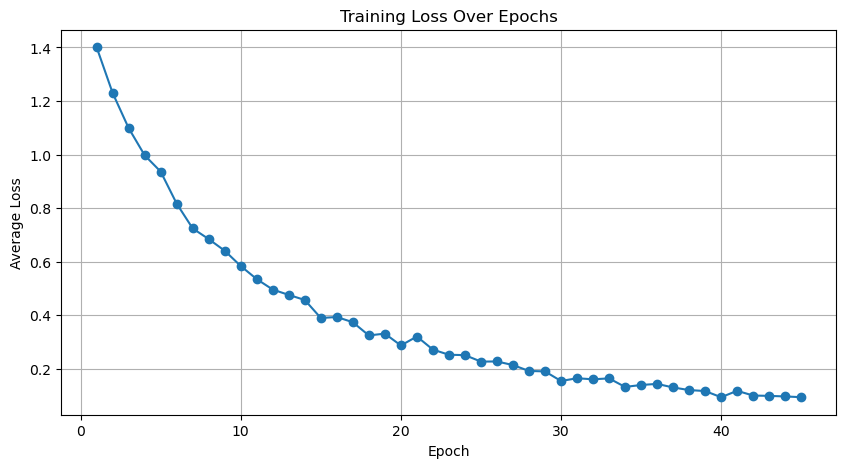

In [145]:
plt.figure(figsize=(10, 5))
plt.plot(range(1, len(loss_history) + 1), loss_history, marker='o')
plt.title("Training Loss Over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Average Loss")
plt.grid(True)
plt.show()

### Section-7: Implementing Masking Implementation

After model is trained we can use it to predict masked words. This function will take a sentence with a `[MASK]` token then process it and give output as the model's top predictions for the masked word.

In [ ]:
#predicting the top_k most likely words for the [MASK] token in a sentence
def predict_masked_word(sentence, top_k=5):
    model.eval()  # set the model to evaluation mode
    
    #tokenizing the input sentence
    text = f"[CLS] {sentence} [SEP]"
    # tokenizing the text and replacing words with their indices
    tokenized_text = [word2idx.get(word, word2idx['[PAD]'])for word in text.lower().replace('.', '').split()]
    # finding the index of the [MASK] token
    masked_index = tokenized_text.index(word2idx['[MASK]'])
    
    # converting to tensor and reshaping
    input_ids = torch.tensor([tokenized_text])
    segment_ids = torch.tensor([[0] * len(tokenized_text)])# segment ids for the input
    attention_mask = torch.tensor([[1] * len(tokenized_text)])# attention mask for the input
    with torch.no_grad():# disabling gradient calculation for inference
        mlm_logits, _ = model(input_ids, segment_ids, attention_mask.float())# getting the logits for MLM

    #getting the logits for the masked token
    mask_logits = mlm_logits[0, masked_index, :]
    probs = torch.softmax(mask_logits, dim=-1)# converting logits to probabilities
    top_k_probs, top_k_indices = torch.topk(probs, top_k)# getting the top k probabilities and indices
    print(f"Original Sentence: '{sentence}'")
    print("-" * 30)
    print(f"Top {top_k} predictions for [MASK]:")
    for i in range(top_k):
        predicted_token = idx2word[top_k_indices[i].item()]# converting index to word
        probability = top_k_probs[i].item()# converting tensor to float
        print(f"{i+1}. '{predicted_token}' (Probability: {probability:.4f})")
    print("\n")